<a href="https://colab.research.google.com/github/Yalda-Ashrafi/pokemon-kmeans-clustering/blob/main/Visualizing%20Output%20Clustering%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv('/content/sample_data/pokemon.csv')

df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


In [ ]:
types=df['Type 1'].isin(['Grass','Fire','Water'])
drop_cols=['Type 1','Type 2', 'Generation','Legendary']
df=df[types].drop(columns=drop_cols)
df.head()

,#,Name,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
0,1,Bulbasaur,318,45,49,49,65,65,45
1,2,Ivysaur,405,60,62,63,80,80,60
2,3,Venusaur,525,80,82,83,100,100,80
3,3,VenusaurMega Venusaur,625,80,100,123,122,120,80
4,4,Charmander,309,39,52,43,60,50,65


In [ ]:
from sklearn.cluster import KMeans
import numpy as np
from sklearn.preprocessing import StandardScaler
kmeans=KMeans(n_clusters=3,random_state=3)
df['cluster']=kmeans.fit_predict(df[['Attack','Defense']])
df.head()

,#,Name,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,cluster
0,1,Bulbasaur,318,45,49,49,65,65,45,0
1,2,Ivysaur,405,60,62,63,80,80,60,0
2,3,Venusaur,525,80,82,83,100,100,80,2
3,3,VenusaurMega Venusaur,625,80,100,123,122,120,80,1
4,4,Charmander,309,39,52,43,60,50,65,0


In [ ]:
centroids=kmeans.cluster_centers_
cen_x=[i[0] for i in centroids]
cen_y=[i[1] for i in centroids]

df['cen_x']=df.cluster.map({0: cen_x[0], 1: cen_x[1], 2: cen_x[2]})
df['cen_y']=df.cluster.map({0: cen_y[0], 1: cen_y[1], 2: cen_y[2]})
colors=['#DF2020','#81DF20','#2095DF']
df['color']=df.cluster.map({0: colors[0], 1: colors[1], 2: colors[2]})
df.head()

,#,Name,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,cluster,cen_x,cen_y,color
0,1,Bulbasaur,318,45,49,49,65,65,45,0,54.155963,53.660550,#DF2020
1,2,Ivysaur,405,60,62,63,80,80,60,0,54.155963,53.660550,#DF2020
2,3,Venusaur,525,80,82,83,100,100,80,2,101.493671,73.455696,#2095DF
3,3,VenusaurMega Venusaur,625,80,100,123,122,120,80,1,85.152174,108.652174,#81DF20
4,4,Charmander,309,39,52,43,60,50,65,0,54.155963,53.660550,#DF2020


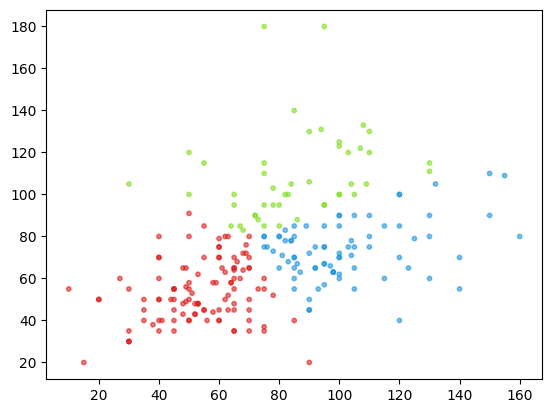

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.scatter(df.Attack,df.Defense,c=df.color, alpha=0.6,s=10)

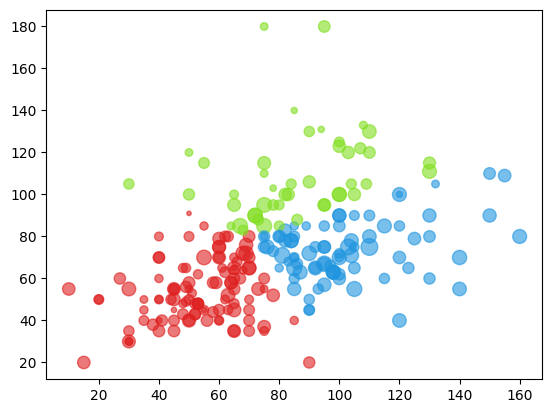

In [ ]:
plt.scatter(df.Attack,df.Defense,c=df.color, alpha=0.6,s=df.Speed)

Text(0, 0.5, 'Defense')

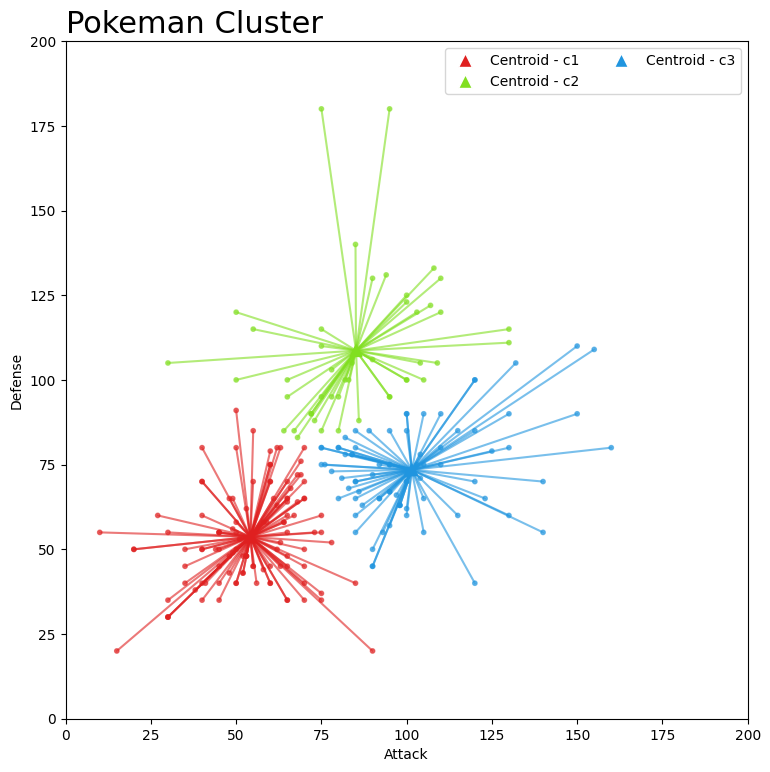

In [ ]:
from matplotlib.lines import Line2D
fig, ax=plt.subplots(1, figsize=(8.8, 8.8))
plt.scatter(df.Attack,df.Defense,c=df.color,alpha=0.6,s=10) # Corrected 'c' to 'color'
plt.scatter(cen_x,cen_y,marker='^',c=colors,s=70)
for idx, val in df.iterrows():
  x=[val.Attack, val.cen_x]
  y=[val.Defense, val.cen_y]
  plt.plot(x,y,c=val.color, alpha=0.6) # Corrected 'c' to 'color'

# Corrected the Line2D instantiation and label formatting
legend_elements = [Line2D([0], [0], marker='^', color='w', label=f'Centroid - c{i+1}',
                           markerfacecolor=mcolor, markersize=10) for i, mcolor in enumerate(colors)]

plt.legend(handles=legend_elements, loc='upper right', ncol=2) # Corrected 'uper right' to 'upper right'

plt.xlim(0,200)
plt.ylim(0,200)
plt.title('Pokeman Cluster', loc='left', fontsize=22)
plt.xlabel('Attack')
plt.ylabel('Defense')